In [1]:
# Importing Libraries
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV,
    cross_validate,
    cross_val_predict
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    make_scorer
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# Loading the sample dataset
original_bank = pd.read_csv("/Users/Owner/Desktop/Bank-Project/Datasets/bank/bank.csv", sep=";")

X = original_bank.drop(columns=["y"])
y = original_bank["y"].map({"no": 0, "yes": 1})

categorical_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object", "string"]).columns.tolist()

print("Dataset shape:", X.shape)
print("\nClass distribution:")
print(y.value_counts())

Dataset shape: (4521, 16)

Class distribution:
y
0    4000
1     521
Name: count, dtype: int64


In [4]:

#Preprocessing 
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# Baseline RF + SMOTE pipeline
rf_baseline_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc"
}

In [5]:
# Baseline RF + SMOTE with 10-fold CV
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

baseline_cv_results = cross_validate(
    rf_baseline_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

baseline_summary = pd.DataFrame([{
    "Scenario": "RF + SMOTE (Baseline, 10-fold CV)",
    "Accuracy": baseline_cv_results["test_accuracy"].mean(),
    "Precision": baseline_cv_results["test_precision"].mean(),
    "Recall": baseline_cv_results["test_recall"].mean(),
    "F1-score": baseline_cv_results["test_f1"].mean(),
    "ROC-AUC": baseline_cv_results["test_roc_auc"].mean()
}])

print(baseline_summary.round(4))

                            Scenario  Accuracy  Precision  Recall  F1-score  \
0  RF + SMOTE (Baseline, 10-fold CV)    0.8914     0.5407  0.3722      0.44   

   ROC-AUC  
0   0.9022  


In [6]:

# Hyperparameter search space
param_grid = {
    "model__n_estimators": [10, 50, 100],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

In [7]:
rf_search = GridSearchCV(
    estimator=Pipeline(steps=[
        ("preprocess", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        ))
    ]),
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    verbose=2,
    n_jobs=-1,
    return_train_score=True,
    refit=True
)

rf_search.fit(X, y)

Fitting 10 folds for each of 162 candidates, totalling 1620 fits
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=10; total time=   0.1s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=10; total time=   0.1s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=10; total time=   0.1s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=10; total time=   0.1s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=10; total time=   0.1s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=10; total time=   0.1s

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [5, 10], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, th

In [8]:
# Best CV configuration
print("Best parameters:")
print(rf_search.best_params_)

print("\nBest mean CV F1:")
print(round(rf_search.best_score_, 4))

print("\nCross-validation configuration:")
print(cv)

Best parameters:
{'model__max_depth': 20, 'model__max_features': None, 'model__min_samples_leaf': 4, 'model__min_samples_split': 5, 'model__n_estimators': 100}

Best mean CV F1:
0.5694

Cross-validation configuration:
StratifiedKFold(n_splits=10, random_state=42, shuffle=True)


In [9]:
# Tuned RF pipeline from GridSearch
rf_tuned = rf_search.best_estimator_

tuned_cv_results = cross_validate(
    rf_tuned,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

tuned_summary = pd.DataFrame([{
    "Scenario": "RF + SMOTE (Tuned GridSearchCV, 10-fold CV)",
    "Accuracy": tuned_cv_results["test_accuracy"].mean(),
    "Precision": tuned_cv_results["test_precision"].mean(),
    "Recall": tuned_cv_results["test_recall"].mean(),
    "F1-score": tuned_cv_results["test_f1"].mean(),
    "ROC-AUC": tuned_cv_results["test_roc_auc"].mean()
}])

print(tuned_summary.round(4))

                                      Scenario  Accuracy  Precision  Recall  \
0  RF + SMOTE (Tuned GridSearchCV, 10-fold CV)    0.8905     0.5204  0.6295   

   F1-score  ROC-AUC  
0    0.5694   0.9037  


In [10]:
# Comparison against the baseline model
results_df = pd.concat([baseline_summary, tuned_summary], ignore_index=True)
print(results_df.round(4))

                                      Scenario  Accuracy  Precision  Recall  \
0            RF + SMOTE (Baseline, 10-fold CV)    0.8914     0.5407  0.3722   
1  RF + SMOTE (Tuned GridSearchCV, 10-fold CV)    0.8905     0.5204  0.6295   

   F1-score  ROC-AUC  
0    0.4400   0.9022  
1    0.5694   0.9037  


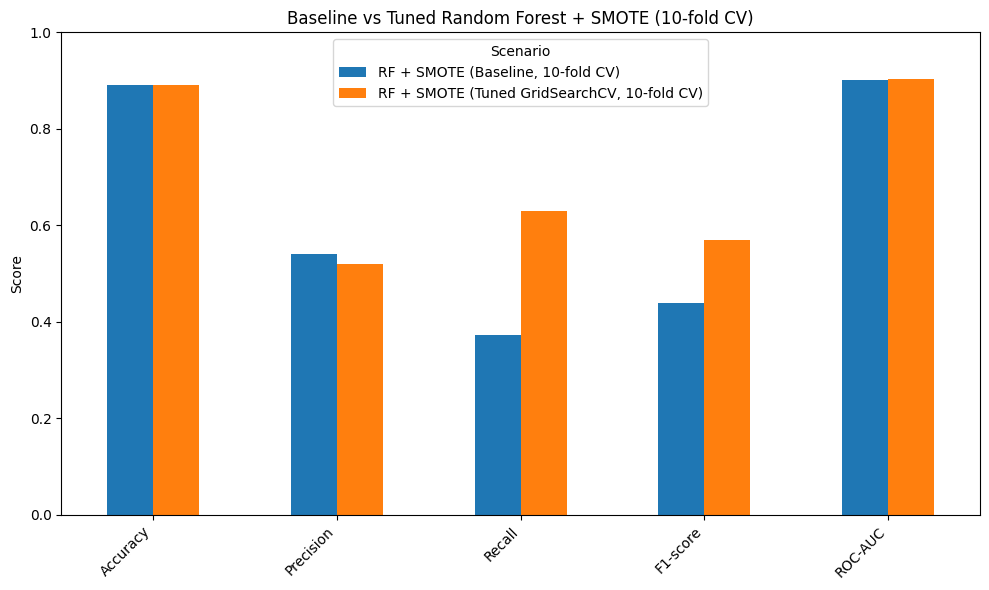

In [11]:
#Plotting the grouped bars
metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

plot_df = results_df.set_index("Scenario")[metrics].T

plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("Baseline vs Tuned Random Forest + SMOTE (10-fold CV)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

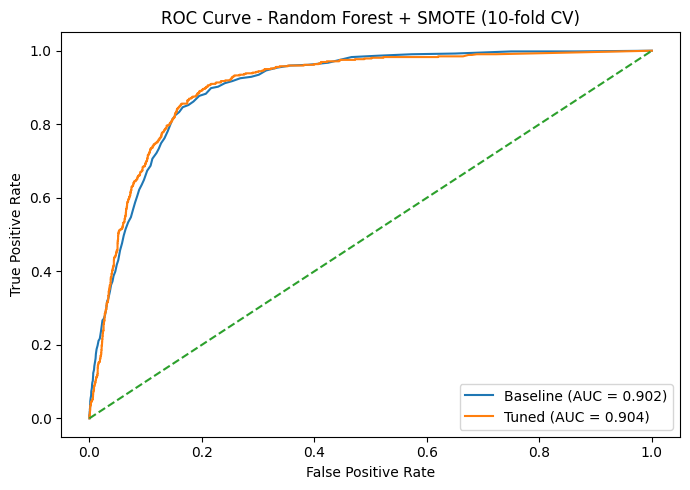

In [12]:
# ROC Curve plotting using out-of-fold probabilities
baseline_oof_proba = cross_val_predict(
    rf_baseline_pipeline,
    X,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

tuned_oof_proba = cross_val_predict(
    rf_tuned,
    X,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

fpr_base, tpr_base, _ = roc_curve(y, baseline_oof_proba)
auc_base = auc(fpr_base, tpr_base)

fpr_tuned, tpr_tuned, _ = roc_curve(y, tuned_oof_proba)
auc_tuned = auc(fpr_tuned, tpr_tuned)

plt.figure(figsize=(7, 5))
plt.plot(fpr_base, tpr_base, label=f"Baseline (AUC = {auc_base:.3f})")
plt.plot(fpr_tuned, tpr_tuned, label=f"Tuned (AUC = {auc_tuned:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest + SMOTE (10-fold CV)")
plt.legend()
plt.tight_layout()
plt.show()

     mean_test_score  std_test_score  param_model__n_estimators  \
158           0.5694          0.0551                        100   
50            0.5690          0.0553                        100   
53            0.5686          0.0571                        100   
161           0.5684          0.0551                        100   
154           0.5631          0.0562                         50   
155           0.5598          0.0553                        100   
46            0.5583          0.0569                         50   
100           0.5581          0.0423                         50   
49            0.5578          0.0506                         50   
43            0.5575          0.0530                         50   

    param_model__max_depth  param_model__min_samples_split  \
158                     20                               5   
50                    None                               5   
53                    None                              10   
161           

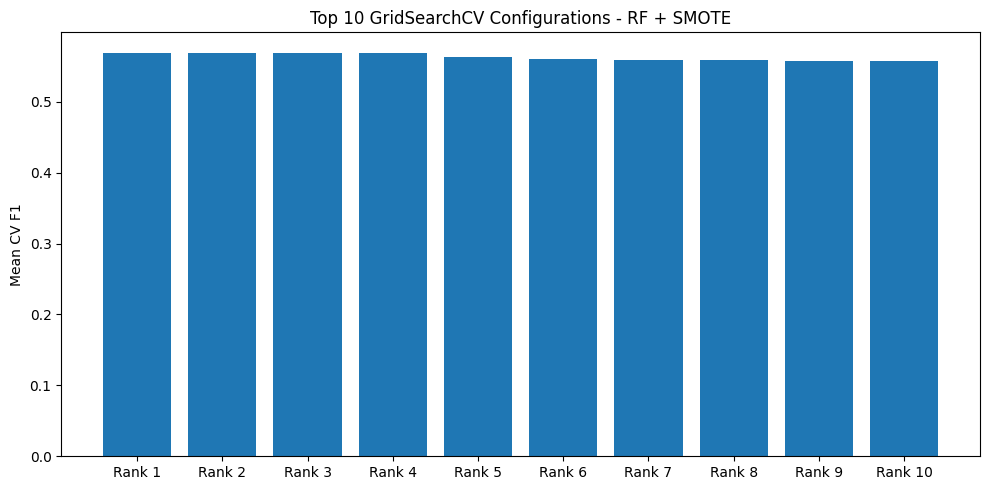

In [13]:
# Top CV configuration
cv_results_df = pd.DataFrame(rf_search.cv_results_).sort_values(
    by="mean_test_score",
    ascending=False
)

top_cv = cv_results_df.head(10).copy()
print(top_cv[[
    "mean_test_score",
    "std_test_score",
    "param_model__n_estimators",
    "param_model__max_depth",
    "param_model__min_samples_split",
    "param_model__min_samples_leaf",
    "param_model__max_features"
]].round(4))

plt.figure(figsize=(10, 5))
plt.bar(range(len(top_cv)), top_cv["mean_test_score"])
plt.xticks(range(len(top_cv)), [f"Rank {i+1}" for i in range(len(top_cv))])
plt.ylabel("Mean CV F1")
plt.title("Top 10 GridSearchCV Configurations - RF + SMOTE")
plt.tight_layout()
plt.show()

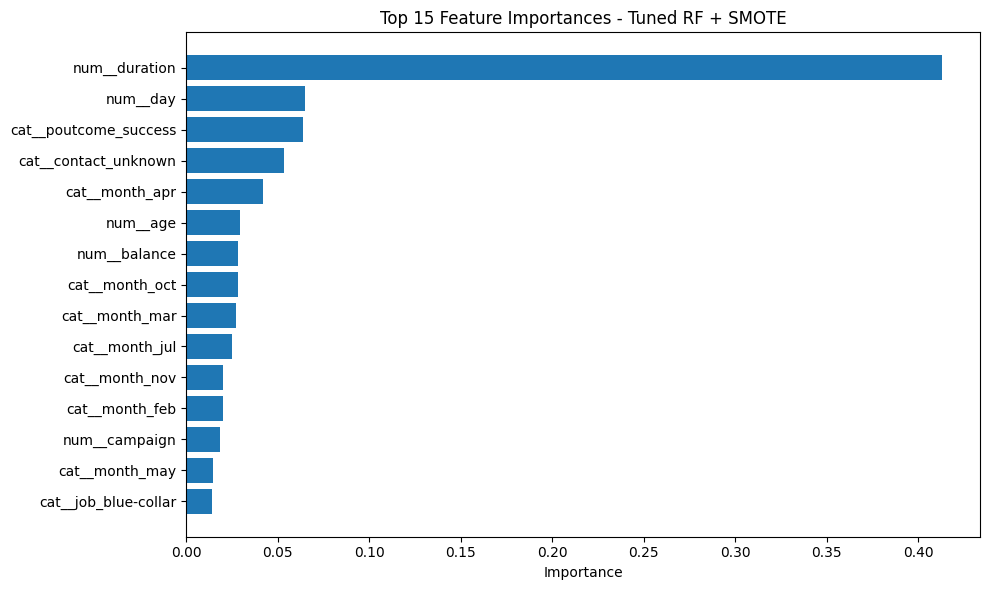

In [14]:
# Fit tuned RF on full dataset to extract feature importance
rf_tuned.fit(X, y)

best_preprocessor = rf_tuned.named_steps["preprocess"]
best_rf = rf_tuned.named_steps["model"]

feature_names = best_preprocessor.get_feature_names_out()

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_rf.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances - Tuned RF + SMOTE")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [15]:
# Fold-by-fold results
baseline_folds_df = pd.DataFrame({
    "Fold": range(1, 11),
    "Accuracy": baseline_cv_results["test_accuracy"],
    "Precision": baseline_cv_results["test_precision"],
    "Recall": baseline_cv_results["test_recall"],
    "F1-score": baseline_cv_results["test_f1"],
    "ROC-AUC": baseline_cv_results["test_roc_auc"]
})

tuned_folds_df = pd.DataFrame({
    "Fold": range(1, 11),
    "Accuracy": tuned_cv_results["test_accuracy"],
    "Precision": tuned_cv_results["test_precision"],
    "Recall": tuned_cv_results["test_recall"],
    "F1-score": tuned_cv_results["test_f1"],
    "ROC-AUC": tuned_cv_results["test_roc_auc"]
})

print("Baseline fold results:")
print(baseline_folds_df.round(4))

print("\nTuned fold results:")
print(tuned_folds_df.round(4))

Baseline fold results:
   Fold  Accuracy  Precision  Recall  F1-score  ROC-AUC
0     1    0.9117     0.6857  0.4528    0.5455   0.8862
1     2    0.8761     0.4412  0.2885    0.3488   0.8902
2     3    0.8894     0.5333  0.3077    0.3902   0.9025
3     4    0.8739     0.4242  0.2692    0.3294   0.9085
4     5    0.8938     0.5500  0.4231    0.4783   0.9183
5     6    0.8938     0.5526  0.4038    0.4667   0.9144
6     7    0.9071     0.6471  0.4231    0.5116   0.9439
7     8    0.8827     0.4857  0.3269    0.3908   0.8750
8     9    0.8894     0.5263  0.3846    0.4444   0.8692
9    10    0.8960     0.5610  0.4423    0.4946   0.9135

Tuned fold results:
   Fold  Accuracy  Precision  Recall  F1-score  ROC-AUC
0     1    0.8962     0.5455  0.6792    0.6050   0.8881
1     2    0.8761     0.4688  0.5769    0.5172   0.8874
2     3    0.8850     0.5000  0.6538    0.5667   0.9024
3     4    0.8827     0.4909  0.5192    0.5047   0.9105
4     5    0.9004     0.5556  0.6731    0.6087   0.9138
5   

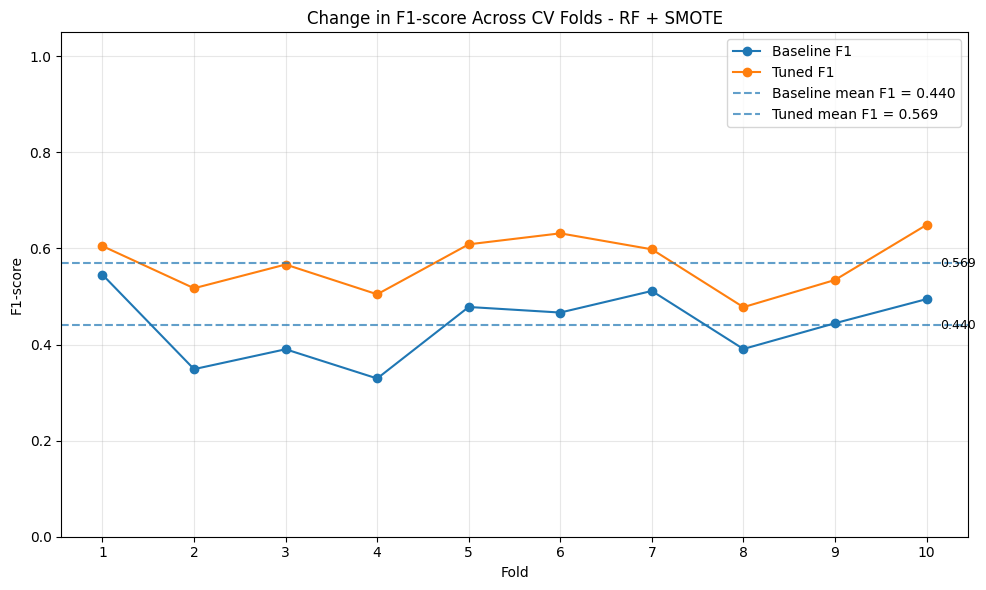

In [19]:
# Plot showing the change across CV folds + mean CV F1 lines

baseline_mean_f1 = baseline_folds_df["F1-score"].mean()
tuned_mean_f1 = tuned_folds_df["F1-score"].mean()

plt.figure(figsize=(10, 6))

# Fold-by-fold F1 lines
plt.plot(
    baseline_folds_df["Fold"],
    baseline_folds_df["F1-score"],
    marker="o",
    label="Baseline F1"
)

plt.plot(
    tuned_folds_df["Fold"],
    tuned_folds_df["F1-score"],
    marker="o",
    label="Tuned F1"
)

# Mean F1 lines
plt.axhline(
    baseline_mean_f1,
    linestyle="--",
    alpha=0.7,
    label=f"Baseline mean F1 = {baseline_mean_f1:.3f}"
)

plt.axhline(
    tuned_mean_f1,
    linestyle="--",
    alpha=0.7,
    label=f"Tuned mean F1 = {tuned_mean_f1:.3f}"
)

# Optional text labels on the right side
plt.text(
    10.15,
    baseline_mean_f1,
    f"{baseline_mean_f1:.3f}",
    va="center",
    fontsize=9
)

plt.text(
    10.15,
    tuned_mean_f1,
    f"{tuned_mean_f1:.3f}",
    va="center",
    fontsize=9
)

plt.xlabel("Fold")
plt.ylabel("F1-score")
plt.title("Change in F1-score Across CV Folds - RF + SMOTE")
plt.xticks(range(1, 11))
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

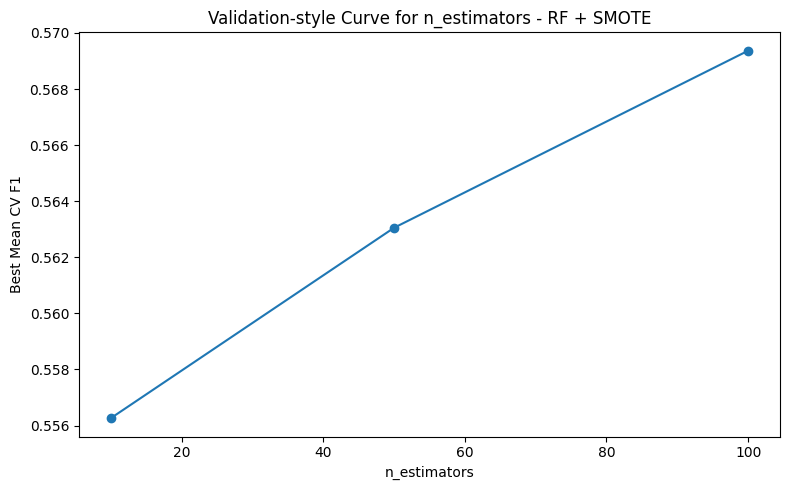

   param_model__n_estimators  mean_test_score
0                         10         0.556261
1                         50         0.563052
2                        100         0.569367


In [17]:
# Build cv results dataframe
cv_results_df = pd.DataFrame(rf_search.cv_results_)

# For each n_estimators value, keep the best mean CV F1 found
best_by_estimators = (
    cv_results_df
    .groupby("param_model__n_estimators")["mean_test_score"]
    .max()
    .reset_index()
    .sort_values("param_model__n_estimators")
)

# Plot validation-style curve
plt.figure(figsize=(8, 5))
plt.plot(
    best_by_estimators["param_model__n_estimators"].astype(int),
    best_by_estimators["mean_test_score"],
    marker="o"
)

plt.xlabel("n_estimators")
plt.ylabel("Best Mean CV F1")
plt.title("Validation-style Curve for n_estimators - RF + SMOTE")
plt.tight_layout()
plt.show()

print(best_by_estimators)

In [18]:
baseline_folds_df
tuned_folds_df
rf_baseline_folds = baseline_folds_df.copy()
rf_baseline_folds["Algorithm"] = "Random Forest"
rf_baseline_folds["Version"] = "Baseline"

rf_tuned_folds = tuned_folds_df.copy()
rf_tuned_folds["Algorithm"] = "Random Forest"
rf_tuned_folds["Version"] = "Tuned"

rf_cv_folds = pd.concat([rf_baseline_folds, rf_tuned_folds], ignore_index=True)

rf_cv_folds.to_csv("rf_cv_folds.csv", index=False)
rf_cv_folds

,Fold,Accuracy,Precision,Recall,F1-score,ROC-AUC,Algorithm,Version
0,1,0.911700,0.685714,0.452830,0.545455,0.886250,Random Forest,Baseline
1,2,0.876106,0.441176,0.288462,0.348837,0.890168,Random Forest,Baseline
2,3,0.889381,0.533333,0.307692,0.390244,0.902548,Random Forest,Baseline
3,4,0.873894,0.424242,0.269231,0.329412,0.908462,Random Forest,Baseline
4,5,0.893805,0.550000,0.423077,0.478261,0.918269,Random Forest,Baseline
5,6,0.893805,0.552632,0.403846,0.466667,0.914399,Random Forest,Baseline
6,7,0.907080,0.647059,0.423077,0.511628,0.943870,Random Forest,Baseline
7,8,0.882743,0.485714,0.326923,0.390805,0.874976,Random Forest,Baseline
8,9,0.889381,0.526316,0.384615,0.444444,0.869231,Random Forest,Baseline
9,10,0.896018,0.560976,0.442308,0.494624,0.913510,Random Forest,Baseline
